# FESTO servo valve — supply characteristic

Supply pressure mapping: upstream = `supply_pressure` (AI ch6), downstream = `pam_valve_pressure` (AI ch1).

In [15]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'sweep_common.py').exists():
    ANALYSIS_DIR = Path('valve_sweep/analysis')
sys.path.insert(0, str(ANALYSIS_DIR.resolve()))

from sweep_common import (
    add_effective_area, load_config, load_sweep_bag, summarize_steps,
)

In [16]:
# Point this to a rosbag directory or directly to its .mcap file.
BAG_PATH = Path('~/koni_log/sweep_high_20260715_142119').expanduser()
CONFIG_PATH = ANALYSIS_DIR / 'calibration.yaml'

config = load_config(CONFIG_PATH)
samples = load_sweep_bag(BAG_PATH, config)
summary = summarize_steps(samples, config['analysis']['tail_duration_s'])
result = add_effective_area(summary, 'supply', config)
print(f'{len(samples):,} AI samples, {len(result)} voltage steps')

9,269 AI samples, 23 voltage steps


In [17]:
columns = [
    'step_index', 'command_voltage_v', 'sample_count',
    'flow_l_min_anr', 'flow_std_l_min',
    'upstream_pressure_kpa_g', 'downstream_pressure_kpa_g',
    'pressure_ratio', 'flow_factor_phi', 'mass_flow_kg_s',
    'effective_area_mm2', 'flow_direction_ok',
    'valid_pressure_ratio', 'flow_near_full_scale',
]
result[columns].round(6)

,step_index,command_voltage_v,sample_count,flow_l_min_anr,flow_std_l_min,upstream_pressure_kpa_g,downstream_pressure_kpa_g,pressure_ratio,flow_factor_phi,mass_flow_kg_s,effective_area_mm2,flow_direction_ok,valid_pressure_ratio,flow_near_full_scale
0,0,5.6,50,5.886019,0.469915,338.119959,0.562561,0.231855,1.000000,0.000118,0.113878,True,True,False
1,1,5.8,50,7.451596,0.214099,337.199841,0.258908,0.231649,1.000000,0.000150,0.144470,True,True,False
2,2,6.0,50,15.232474,0.310713,335.759382,4.107234,0.241217,1.000000,0.000306,0.296297,True,True,False
3,3,6.2,50,39.007859,0.395718,325.252036,16.526550,0.276273,1.000000,0.000783,0.777456,True,True,False
4,4,6.4,50,50.145114,1.017499,314.979653,21.385025,0.294760,1.000000,0.001006,1.024091,True,True,False
5,5,6.6,50,52.003047,0.247130,289.129348,57.521441,0.406825,0.999935,0.001044,1.132385,True,True,False
6,6,6.8,51,53.874369,0.330943,250.382856,95.525977,0.559700,0.963927,0.001081,1.326476,True,True,False
7,7,7.0,51,55.095087,0.219885,224.663931,119.042824,0.675998,0.887921,0.001106,1.524910,True,True,False
8,8,7.2,51,56.003456,0.233884,211.617463,131.235081,0.743140,0.820323,0.001124,1.679884,True,True,False
9,9,7.4,50,56.425114,0.243954,202.027799,138.931373,0.792003,0.757066,0.001132,1.817519,True,True,False


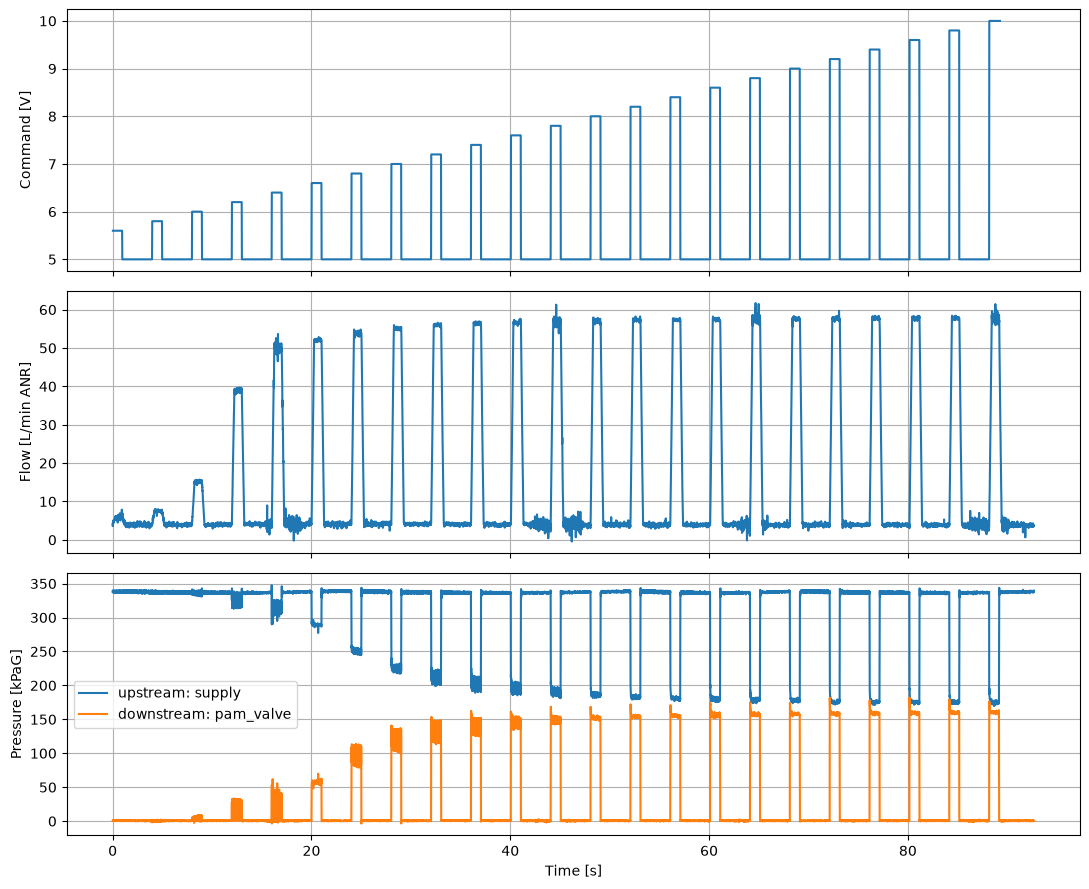

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(samples['time_s'], samples['command_voltage_v'])
axes[0].set_ylabel('Command [V]')
axes[1].plot(samples['time_s'], samples['flow_l_min_anr'])
axes[1].set_ylabel('Flow [L/min ANR]')
axes[2].plot(samples['time_s'], samples['supply_pressure_kpa_g'], label='upstream: supply')
axes[2].plot(samples['time_s'], samples['pam_valve_pressure_kpa_g'], label='downstream: pam_valve')
axes[2].set_ylabel('Pressure [kPaG]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
for axis in axes:
    axis.grid(True)
fig.tight_layout()

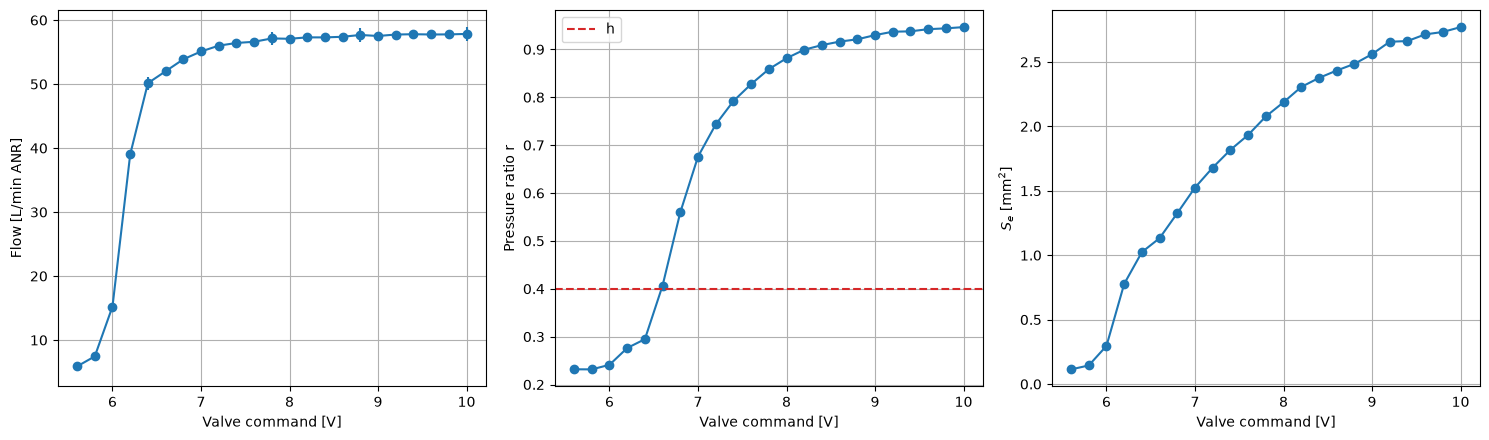

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].errorbar(result['command_voltage_v'], result['flow_l_min_anr'], yerr=result['flow_std_l_min'], marker='o')
axes[0].set_ylabel('Flow [L/min ANR]')
axes[1].plot(result['command_voltage_v'], result['pressure_ratio'], marker='o')
axes[1].axhline(config['model']['critical_pressure_ratio'], color='tab:red', linestyle='--', label='h')
axes[1].set_ylabel('Pressure ratio r')
axes[1].legend()
axes[2].plot(result['command_voltage_v'], result['effective_area_mm2'], marker='o')
axes[2].set_ylabel(r'$S_e$ [mm$^2$]')
for axis in axes:
    axis.set_xlabel('Valve command [V]')
    axis.grid(True)
fig.tight_layout()

In [20]:
problems = result.loc[
    (~result['flow_direction_ok'])
    | (~result['valid_pressure_ratio'])
    | result['flow_near_full_scale']
]
if problems.empty:
    print('No direction, pressure-ratio, or flow-range warnings.')
else:
    display(problems[columns])

No direction, pressure-ratio, or flow-range warnings.


In [21]:
# Optional CSV export
# output_path = BAG_PATH.with_name(BAG_PATH.name + '_supply_analysis.csv')
# result.to_csv(output_path, index=False)
# output_path